**Install the required libraries**

In [ ]:
# Install libraries to use matminer.
!pip install pyyaml -q
!pip install six -q
!pip install matminer[citrine] -q
!pip install citrination-client -q
!pip install --upgrade pandas==2.2.2 -q
!pip install pymatgen -q
!pip install --upgrade matplotlib==3.8.0 -q
!git clone https://github.com/CMDDclass/MS697-material.git

# **1. Train and Test ML algorithm: Heating and Cooling Load Case**

**Loading libraries we want to use in this notebook**

(you don't need to load all of libraries at first and you can load it anytime and anywhere)

In [ ]:
import pandas as pd # a software library written for the Python programming language for data manipulation and analysis. In particular, it offers data structures and operations for manipulating numerical tables and time series
import seaborn as sns # Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import numpy as np # a software library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
import matplotlib.pyplot as plt # a plotting library for the Python programming language

# sklearn is a machine learning software library for the Python programming language. It features various classification, regression and clustering algorithms including support vector machines, random forests, gradient boosting,
# k-means and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.
from sklearn.datasets import fetch_openml
from sklearn import linear_model, metrics, model_selection
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

Loading the boston house-prices dataset from the sklearn repository

In [ ]:
# Load the California housing dataset
#Energy = pd.read_excel('/content/MS697-material/data/ENB2012_data.xlsx')
Energy = pd.read_excel('../data/ENB2012_data.xlsx')

In [ ]:
# Print the key values of data

# Print the total row and column length of the dataset

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')
(768, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
rename_dict = {
    "X1": "Relative_Compactness",
    "X2": "Surface_Area",
    "X3": "Wall_Area",
    "X4": "Roof_Area",
    "X5": "Overall_Height",
    "X6": "Orientation",
    "X7": "Glazing_Area",
    "X8": "Glazing_Area_Distribution",
    "Y1": "Heating_Load",
    "Y2": "Cooling_Load"
}

df = df.rename(columns=rename_dict)
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


**Feature selection**

Sometimes, the input variables may not be directly related to the interested target. Hence, a feature selection step is necessary. There are many different methods for selecting features. Here we will go over a simple implementation in scikit-learn.

In [ ]:
# Function that returns feature names


In [ ]:
# Set the input features (X1 to X8):
#   Relative_Compactness
#   Surface_Area
#   Wall_Area
#   Roof_Area
#   Overall_Height
#   Orientation
#   Glazing_Area
#   Glazing_Area_Distribution


# Target variables(Y1, Y2):
#  Heating_Load
#  Cooling_Load


In [ ]:
# Select the top 5 features by using 'SelectKBest'


Selected features ['Relative_Compactness' 'Surface_Area' 'Wall_Area' 'Roof_Area'
 'Overall_Height']


**1. Train ML algorithm**

/tmp/ipykernel_70671/4280928225.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(1.6, 4, "Heating_Load = {:.3f} * Relative_Compactness + {:.3f}".format(float(a), float(b)) , fontsize=15, color = "r")


Text(1.6, 4, 'Heating_Load = 59.359 * Relative_Compactness + -23.053')

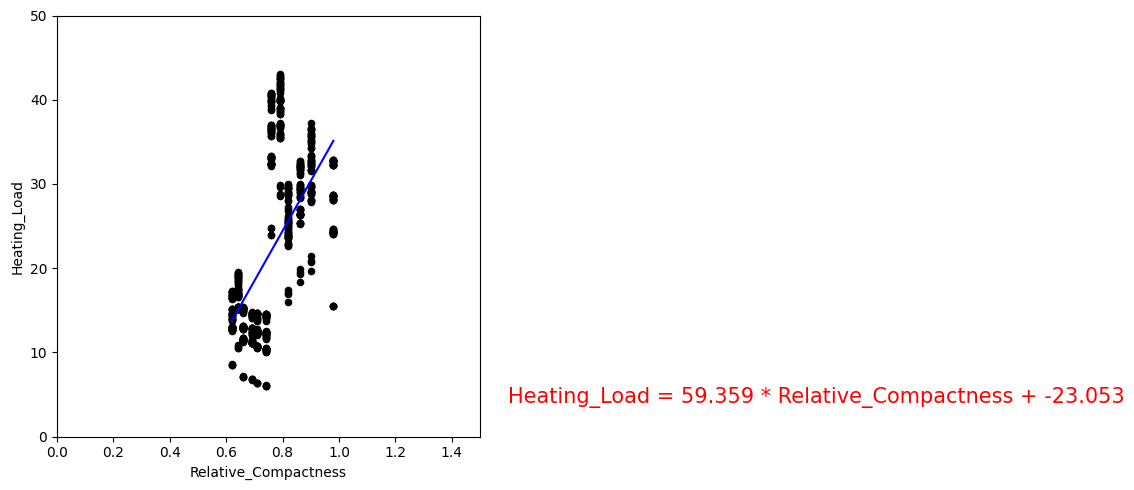

In [ ]:
# Train about the average number of rooms and house quality by using 'LinearRegression'
# X : the feature used for training (Relative_Compactness, reshaped into a DataFrame)
# y : the target variable (Heating_Load)


# Get the slope and intercept from the trained linear regression model

#df.plot(kind='scatter', x ="Relative_Compactness", y="Heating_Load", figsize=(5, 5), color='black', xlim=(0,1.5), ylim=(0,50))
#plt.tight_layout()
#plt.plot(df['Relative_Compactness'], prediction, color='b')
#plt.text(1.6, 4, "Heating_Load = {:.3f} * Relative_Compactness + {:.3f}".format(float(a), float(b)) , fontsize=15, color = "r")

**2. Train & Test ML algorithm**



In [ ]:
# Classify into training dataset and testing dataset using only "Surface_Area" feature
# x_data : using 'Surface_Area' as the single predictor variable
# y_data : the target variable to be predicted, 'Heating_Load'

# Split the data into training and test sets('train_test_split')


Size of training set: 691, test set: 77


score: 0.39
Mean Squared Error: 62.29
RMSE (* 1000$): 7.89


(0.0, 50.0)

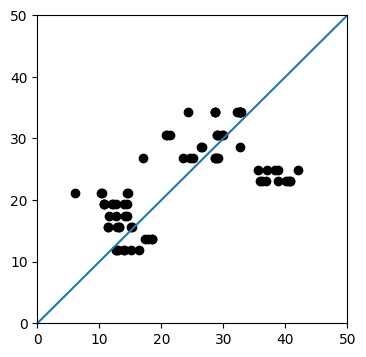

In [ ]:
# Train Linear regression model('fit')

# Test with prediction by using R2 score('metrics.r2_score')

# Print prediction values about test set
#plt.figure(figsize=(4,4))
#plt.scatter(y_test, y_predict_test, color='k')
#plt.plot([0,50],[0,50])
#plt.xlim(0, 50)
#plt.ylim(0, 50)

score: 0.92
Mean Squared Error: 8.85
RMSE (* 1000$): 2.97


(0.0, 50.0)

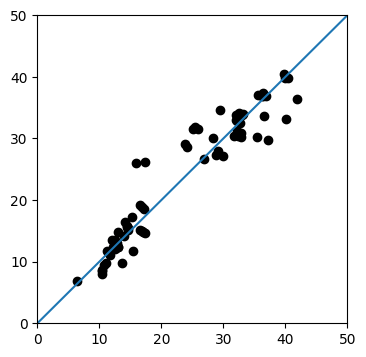

In [ ]:
# Train with all features
# 1) Build feature matrix X and target vector y
#    x_data: all input features
#    y_data: the target column 'Heating_Load' from UCI Energy Efficiency dataset (Y1)

# 2) Train/Test split
#    - test_size=0.1: keep 10% as held-out test set for final evaluation

# 3) Instantiate and fit a Linear Regression model on the training set
#    `fit` finds the best-fitting coefficients (coef_) and intercept_

# 4) Evaluate on the held-out test set (unseen during training)
#    - R² closer to 1.0 is better
#    - MSE is average squared error; RMSE is its square root (same unit as target)

#plt.figure(figsize=(4,4))
#plt.scatter(y_test, y_predict_test, color='k')
#plt.plot([0,50],[0,50])
#plt.xlim(0, 50)
#plt.ylim(0, 50)

Benchmark the optimial number of features

Selected 1 features Index(['Overall_Height'], dtype='object')
average of score: 78.76
Selected 2 features Index(['Roof_Area', 'Overall_Height'], dtype='object')
average of score: 78.64
Selected 3 features Index(['Surface_Area', 'Roof_Area', 'Overall_Height'], dtype='object')
average of score: 83.41
Selected 4 features Index(['Relative_Compactness', 'Surface_Area', 'Roof_Area', 'Overall_Height'], dtype='object')
average of score: 83.79
Selected 5 features Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height'],
      dtype='object')
average of score: 83.88
Selected 6 features Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Glazing_Area'],
      dtype='object')
average of score: 91.35
Selected 7 features Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution'],
      dtype='object')
average of score: 91.50
Selec

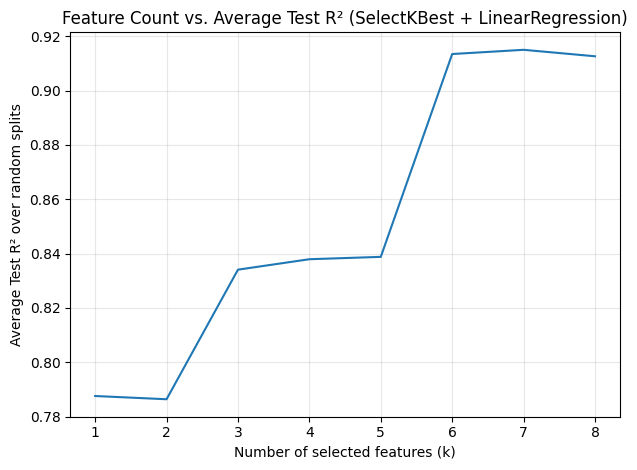

In [ ]:
# ---------------------------------------------------------------
# TASK: Implement a procedure to search the optimal number of features
#       by evaluating average R² scores as the number of features increases.
#
# STEPS TO FOLLOW:
#
# 1) Data Preparation
#    - Extract input features (x_data_set) from dataframe `df`
#    - Extract target variable 'Heating_Load' as y_data
#
# 2) Feature Selection
#    - Use SelectKBest with f_regression
#    - For each k = 1 ... total number of features:
#         * Select top-k features
#         * Print the selected feature names
#
# 3) Model Training & Validation
#    - Restrict x_data to the selected features
#    - Repeat the following 1000+ times for stability:
#         * Randomly split data into train (90%) / test (10%)
#         * Fit a LinearRegression model on the training set
#         * Predict on the test set
#         * Compute evaluation metrics: R², MSE, RMSE
#         * Accumulate the scores
#
# 4) Average Performance
#    - After all repetitions, compute the average R²
#    - Append the average score to the results list `all`
#
# 5) Visualization
#    - Plot number of features (k) on the x-axis
#    - Plot average R² score on the y-axis
#    - This shows how predictive performance changes with feature count
# ---------------------------------------------------------------

plt.plot([i for i in range(1, len(all)+1)], all)
plt.xlabel("Number of selected features (k)")
plt.ylabel("Average Test R² over random splits")
plt.title("Feature Count vs. Average Test R² (SelectKBest + LinearRegression)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
